# Acquisition Function Output Analysis

Load a saved active-learning `output_dict` HDF5 file and start with the mean test reduced-error plot.

In [1]:
%matplotlib inline

from pathlib import Path
import re

import h5py
import numpy as np
import matplotlib.pyplot as plt


cwd = Path.cwd()
stm_dir = cwd / "notebooks" / "STM" if (cwd / "notebooks" / "STM").exists() else cwd
results_dir = stm_dir / "active_learning_results_ms1"

h5_files = sorted(results_dir.glob("*.h5"), key=lambda path: path.stat().st_mtime)
if not h5_files:
    raise FileNotFoundError(f"No .h5 files found in {results_dir}")


# By default, analyze the newest saved acquisition result. Replace this with
# a specific Path(...) if you want to load a different run.
output_file = h5_files[-1]
output_file



error_type = "cos"  # "L1", "L2", or "cos"
acquisition_iterations = 50
num_new_points = 5
output_file = results_dir / (
    f"al_im2spec_{error_type}_WS32_latent5_appendpad_"
    f"{acquisition_iterations}iters_{num_new_points}pts_distanceacq.h5"
)


In [2]:
def plot_reduced_errors_and_scales(errors, coords_reduced, aq_indices=None):
    xs = coords_reduced[:, 0] * 0.4833
    ys = coords_reduced[:, 1] * 0.4833
    scales = coords_reduced[:, 2]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sc0 = axes[0].scatter(xs, ys, c=errors, s=80)
    axes[0].set_title("Reduced Minimum Errors, mean = {:.3f}".format(np.mean(errors)))
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0], label="Minimum Error")

    sc1 = axes[1].scatter(xs, ys, c=scales, s=80)
    axes[1].set_title("Best Scale at Each (x, y)")
    axes[1].set_xlabel("x(nm)")
    axes[1].set_ylabel("y(nm)")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1], label="Best Scale")

    if aq_indices is not None and len(aq_indices) > 0:
        aq_indices = np.asarray(aq_indices, dtype=int)

        axes[0].scatter(
            xs[aq_indices],
            ys[aq_indices],
            marker="x",
            s=120,
            linewidths=2,
            label="Acquisition points",
        )
        axes[0].legend()

    plt.tight_layout()
    plt.show()


def load_h5_ragged(filename):
    data_dict = {}

    with h5py.File(filename, "r") as f:
        for key in f.keys():
            group = f[key]

            values = []
            for i in range(len(group)):
                values.append(group[str(i)][()])

            data_dict[key] = values

    return data_dict


def infer_num_new_points(output_dict, output_file, fallback=5):
    match = re.search(r"_(\d+)pts_", output_file.name)
    if match:
        return int(match.group(1))

    train_indices = output_dict.get("train_indices", [])
    if len(train_indices) > 1:
        return int(len(train_indices[1]) - len(train_indices[0]))

    return fallback



In [3]:


output_dict = load_h5_ragged(output_file)
{key: len(value) for key, value in output_dict.items()}

{'im2spec_test_mismatches': 50,
 'pred_error_test': 50,
 'predicted_errors_all': 50,
 'reduced_coords': 50,
 'reduced_errors': 50,
 'reduced_errors_im2spec': 50,
 'test_indices': 50,
 'train_indices': 50}

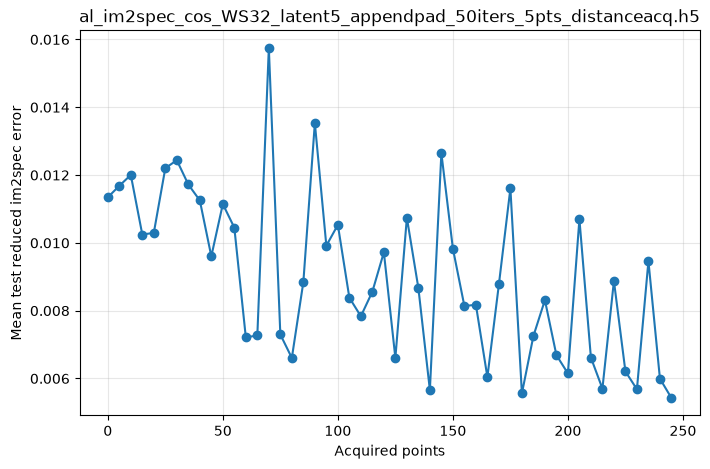

In [4]:


train_indices_arr = output_dict["train_indices"]
test_indices_arr = [indices.astype(int) for indices in output_dict["test_indices"]]
reduced_errors_arr = np.array(output_dict["reduced_errors_im2spec"])

num_saved_iterations = len(reduced_errors_arr)
points_per_iteration = infer_num_new_points(output_dict, output_file)

test_reduced_errors = [
    reduced_errors_arr[i][test_indices_arr[i]]
    for i in range(num_saved_iterations)
]

mean_test_reduced_errors = [
    np.mean(test_reduced_errors[i])
    for i in range(num_saved_iterations)
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(num_saved_iterations) * points_per_iteration,
    mean_test_reduced_errors,
    marker="o",
)
ax.set_xlabel("Acquired points")
ax.set_ylabel("Mean test reduced im2spec error")
ax.set_title(Path(output_file).name)
ax.grid(True, alpha=0.3)
plt.show()

Plotting iteration -1 from al_im2spec_cos_WS32_latent5_appendpad_50iters_5pts_distanceacq.h5


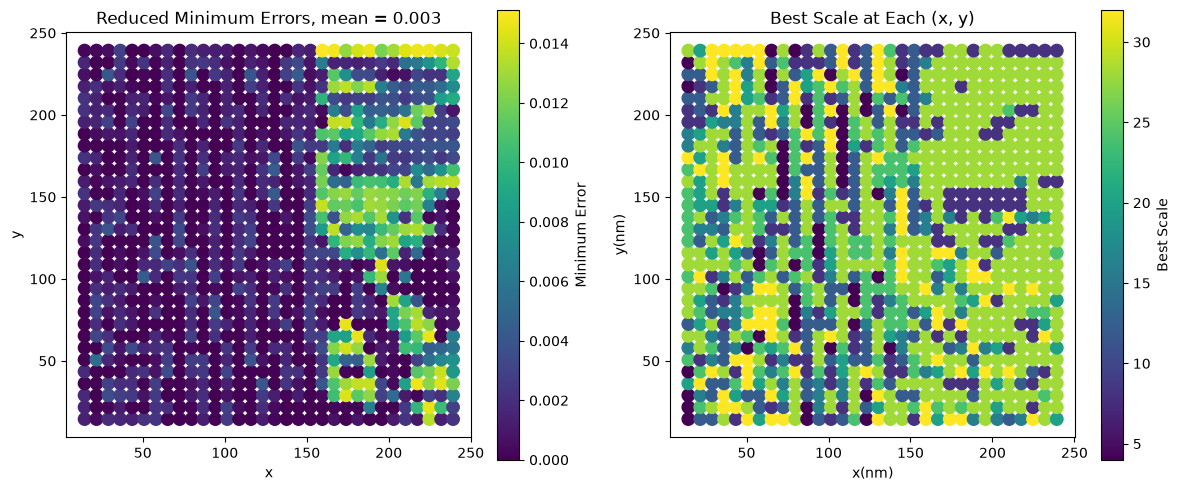

In [5]:
plot_iteration = -1
error_key = "reduced_errors"

if "reduced_coords" not in output_dict:
    raise KeyError(
        "This output file does not contain reduced_coords. "
        "Re-run stm_ms_acqfn_script.py after the reduced_coords save change."
    )

reduced_errors_to_plot = np.asarray(output_dict[error_key][plot_iteration])
reduced_coords_to_plot = np.asarray(output_dict["reduced_coords"][plot_iteration])

print(f"Plotting iteration {plot_iteration} from {Path(output_file).name}")
plot_reduced_errors_and_scales(reduced_errors_to_plot, reduced_coords_to_plot)

# Compare with random.

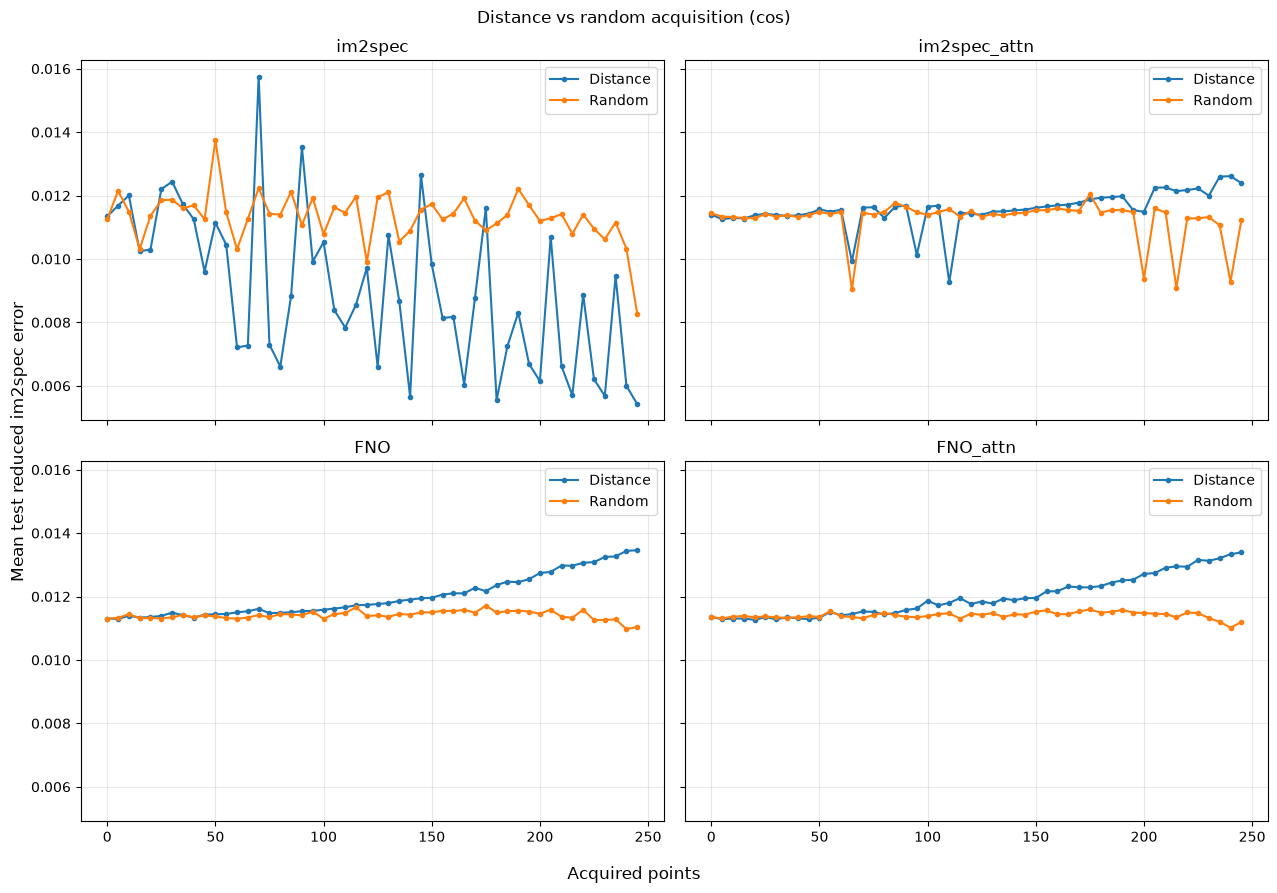

In [6]:
def calculate_mean_test_reduced_im2spec_error(output_dict):
    reduced_errors = output_dict["reduced_errors_im2spec"]
    test_indices = output_dict["test_indices"]

    if len(reduced_errors) != len(test_indices):
        raise ValueError(
            "reduced_errors_im2spec and test_indices have different iteration counts"
        )

    return np.asarray([
        np.mean(np.asarray(errors)[np.asarray(indices, dtype=int)])
        for errors, indices in zip(reduced_errors, test_indices)
    ])


model_configs = {
    "im2spec": "appendpad",
    "im2spec_attn": "appendpad",
    "FNO": "appendinterpolate",
    "FNO_attn": "appendinterpolate",
}
comparison_results = {}

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for ax, (model_type, append_mode) in zip(axes.flat, model_configs.items()):
    comparison_results[model_type] = {}

    for acquisition in ("distance", "random"):
        output_file = results_dir / (
            f"al_{model_type}_{error_type}_WS32_latent5_{append_mode}_"
            f"{acquisition_iterations}iters_{num_new_points}pts_"
            f"{acquisition}acq.h5"
        )
        if not output_file.exists():
            raise FileNotFoundError(output_file)

        output_dict = load_h5_ragged(output_file)
        mean_test_reduced_im2spec_error = (
            calculate_mean_test_reduced_im2spec_error(output_dict)
        )
        points_per_iteration = infer_num_new_points(output_dict, output_file)
        acquired_points = (
            np.arange(len(mean_test_reduced_im2spec_error))
            * points_per_iteration
        )

        comparison_results[model_type][acquisition] = {
            "output_file": output_file,
            "output_dict": output_dict,
            "mean_test_reduced_im2spec_error": (
                mean_test_reduced_im2spec_error
            ),
        }

        ax.plot(
            acquired_points,
            mean_test_reduced_im2spec_error,
            marker="o",
            markersize=3,
            label=acquisition.capitalize(),
        )

    ax.set_title(model_type)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.supxlabel("Acquired points")
fig.supylabel("Mean test reduced im2spec error")
fig.suptitle(f"Distance vs random acquisition ({error_type})")
fig.tight_layout()
plt.show()

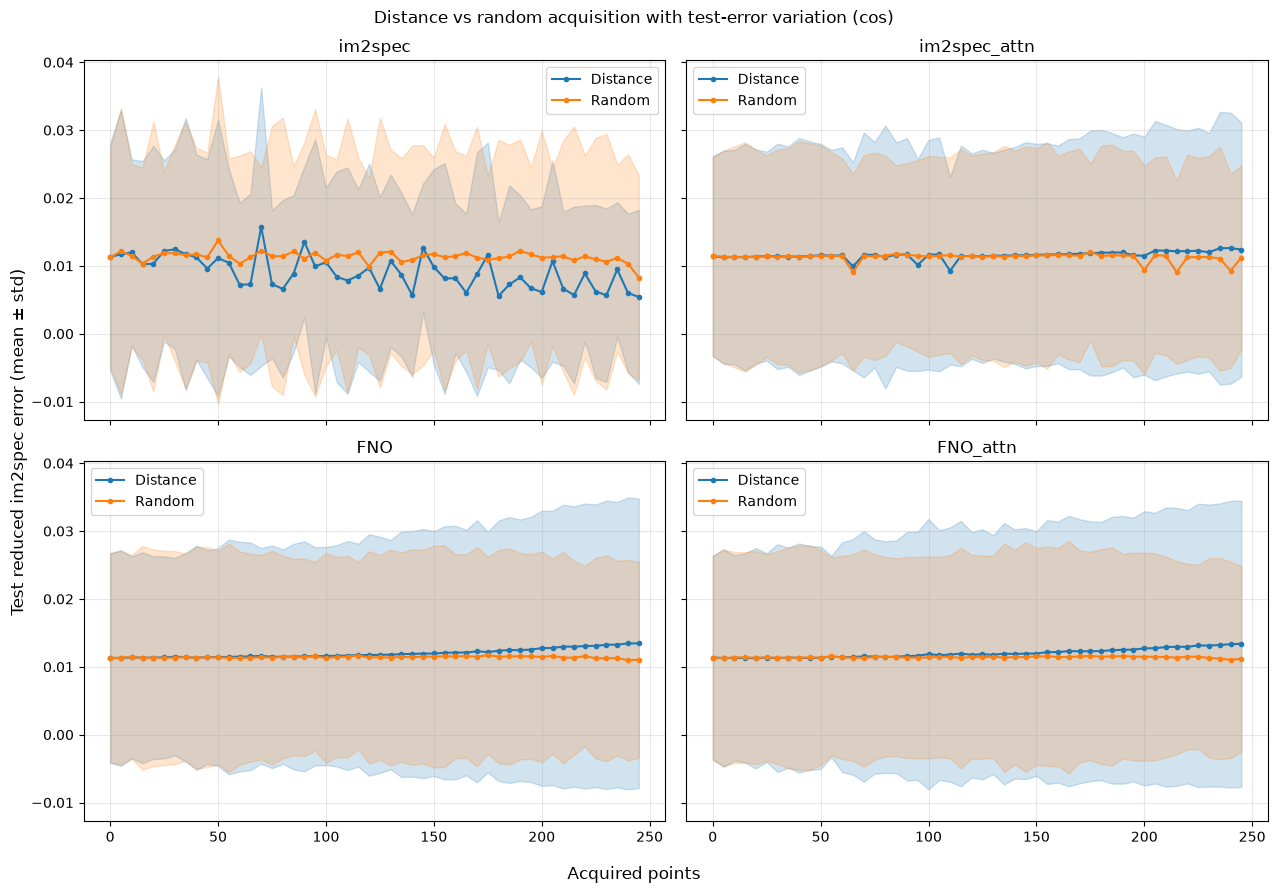

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for ax, (model_type, acquisition_results) in zip(
    axes.flat, comparison_results.items()
):
    for acquisition, result in acquisition_results.items():
        output_dict = result["output_dict"]
        output_file = result["output_file"]

        test_reduced_im2spec_errors = [
            np.asarray(errors)[np.asarray(indices, dtype=int)]
            for errors, indices in zip(
                output_dict["reduced_errors_im2spec"],
                output_dict["test_indices"],
            )
        ]
        mean_errors = result["mean_test_reduced_im2spec_error"]
        std_errors = np.asarray([
            np.std(errors) for errors in test_reduced_im2spec_errors
        ])
        result["std_test_reduced_im2spec_error"] = std_errors

        points_per_iteration = infer_num_new_points(output_dict, output_file)
        acquired_points = np.arange(len(mean_errors)) * points_per_iteration

        mean_line = ax.plot(
            acquired_points,
            mean_errors,
            marker="o",
            markersize=3,
            label=acquisition.capitalize(),
        )[0]
        ax.fill_between(
            acquired_points,
            mean_errors - std_errors,
            mean_errors + std_errors,
            color=mean_line.get_color(),
            alpha=0.2,
        )

    ax.set_title(model_type)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.supxlabel("Acquired points")
fig.supylabel("Test reduced im2spec error (mean ± std)")
fig.suptitle(
    f"Distance vs random acquisition with test-error variation ({error_type})"
)
fig.tight_layout()
plt.show()
